In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from collections import defaultdict
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import torch
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('husl'),)

from conf import conf
from dafm import datasets, models, utils

In [5]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [7]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=['model=FlowMatching', 'dataset=DoubleWell'])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching',
     out_dir='/root/workspace/out/dafm',
     run_subdir='runs',
     prediction_filename='trajectories.parquet',
     device='cuda',
     alt_id='j1wtr787',
     rng_seed=2376999025,
     fit=True,
     id=2,
     dataset=DoubleWell(predicted_state_count=1000,
                        time_step_count=100,
                        time_step_size=0.1,
                        sa_inheritance='DoubleWell',
                        id=1,
                        model_std=0.2,
                        observation_std=0.1,
                        true_state_initial_condition_std=0.02,
                        predicted_state_initial_condition_std=0.2),
     model=FlowMatching(sa_inheritance='FlowMatching',
                        id=1,
                        epoch_count=600,
                        batch_size=1000,
                        shuffle_training_samples=True,
                        embedding_dimension=50,
         

In [49]:
rng = torch.Generator(device=cfg.device).manual_seed(cfg.rng_seed)
dynamics = datasets.get_dynamics_dataset(cfg.dataset, rng)

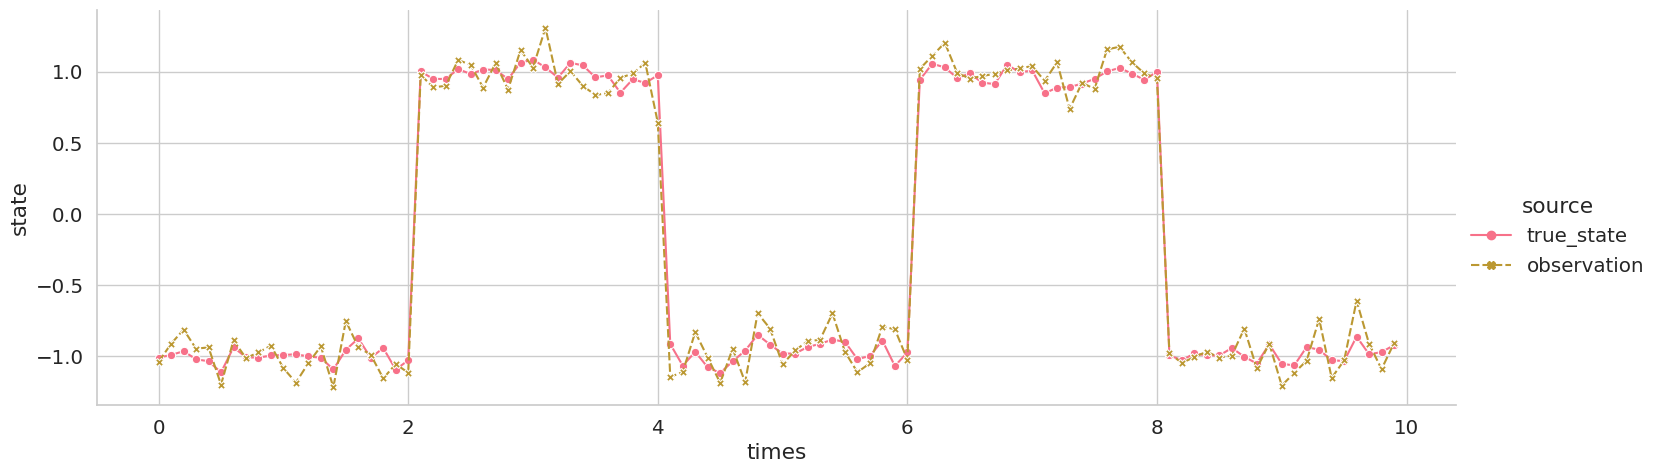

In [50]:
df = (
    pd.DataFrame({
        k: rearrange(v, 't s -> (t s)').cpu().numpy()
        for k, v in dynamics.data.items()
        if k in ['times', 'true_state', 'observation']
    })
    .melt(id_vars='times', var_name='source', value_name='state')
)
sns.relplot(
    data=df,
    kind='line',
    x='times',
    y='state',
    hue='source',
    style='source',
    markers=True,
    aspect=3,
)